# Experiments with Maximal Lotteries

In [1]:
from utils_3 import PairwiseData, Population
import numpy as np
import os

for k in ["HF_HOME", "HF_HUB_CACHE", "HF_DATASETS_CACHE", "XDG_CACHE_HOME"]:
    print(k, os.environ.get(k))

from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k")
ds = dict(ds)

pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)
candidate_labels = [pw.idx_to_candidates[i] for i in range(len(pw.idx_to_candidates))]

HF_HOME /home/jennifer/scratch/hf
HF_HUB_CACHE None
HF_DATASETS_CACHE /home/jennifer/scratch/hf/datasets
XDG_CACHE_HOME None


/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 30/30 [00:01<00:00, 26.52it/s]


## Marginal win-rate matrix

In [2]:
winners = pw.winners
losers = pw.losers

ij_wins = np.zeros((pw.M, pw.M))
for w, l in zip(winners, losers):
    ij_wins[w, l] += 1

total = ij_wins + ij_wins.T
# marginal win-rate: (wins_ij - wins_ji) / (wins_ij + wins_ji); 0 where undefined
with np.errstate(invalid="ignore", divide="ignore"):
    margin_wins = np.where(total > 0, (ij_wins - ij_wins.T) / total, 0.0)

np.fill_diagonal(margin_wins, 0.0)
print("margin_wins shape:", margin_wins.shape)
print("undefined pairs set to 0:", (total == 0).sum())

margin_wins shape: (30, 30)
undefined pairs set to 0: 30


In [20]:
# mu_weight[i,j] = P(unordered pair {i,j} | one of them is i)
#                = total[i,j] / sum_k total[i,k]
# Zero for pairs never observed, so undefined pairs are automatically ignored.
count_i = total.sum(axis=1, keepdims=True)   # total comparisons involving i
mu_weight = np.where(count_i > 0, total / count_i, 0.0)
np.fill_diagonal(mu_weight, 0.0)
print("mu_weight row sums (should be 1 for observed candidates):", mu_weight.sum(axis=1))

mu_weight row sums (should be 1 for observed candidates): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


## Maximal lotteries helper

In [21]:
from scipy.optimize import linprog


def maximal_lotteries_from_win_rates(margins, tie_tol=1e-12):
    C = margins.shape[0]
    result = linprog(
        c=np.zeros(C, dtype=float),
        A_ub=-margins.T,
        b_ub=np.zeros(C, dtype=float),
        A_eq=np.ones((1, C), dtype=float),
        b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * C,
        method="highs",
    )
    if not result.success:
        raise RuntimeError(f"Maximal lottery solve failed: {result.message}")
    lottery = np.asarray(result.x, dtype=float)
    lottery[np.abs(lottery) < tie_tol] = 0.0
    lottery /= lottery.sum()
    ranking = np.argsort(-lottery)
    return lottery, ranking

## Maximal lotteries with argmax

In [22]:
def argmax_lottery_from_wins(margins, tie_tol=1e-12):
    """
    Peeling ranking via maximal lotteries (argmax variant).

    Each round: compute maximal lottery on remaining candidates,
    select the candidate with the highest lottery mass, remove and repeat.
    """
    C = margins.shape[0]
    remaining = list(range(C))
    ranking = []
    round_lotteries = []

    while remaining:
        rem_idx = np.asarray(remaining, dtype=int)
        rem_margins = margins[np.ix_(rem_idx, rem_idx)]
        lottery, _ = maximal_lotteries_from_win_rates(rem_margins, tie_tol=tie_tol)
        round_lotteries.append(lottery.copy())

        winner_local = int(np.argmax(lottery))
        winner_global = remaining[winner_local]
        ranking.append(winner_global)
        remaining.pop(winner_local)

    return round_lotteries, np.array(ranking, dtype=int)

In [23]:
round_lotteries_argmax, ranking_argmax = argmax_lottery_from_wins(margins=margin_wins)
print("argmax ranking:", ranking_argmax)
for i, lot in enumerate(round_lotteries_argmax):
    print(f"round {i}: {lot}")

argmax ranking: [ 1  7  5 14  2 20 21 23  4  3 16  9 17 27  0 18 25 22 24 29  6 26 12 13
 11 28  8 10 19 15]
round 0: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
round 1: [0.         0.         0.         0.         0.36085982 0.
 0.42172774 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.21741244 0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
round 2: [0.         0.         0.         0.         0.53109133 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.30196102 0.         0.         0.16694766 0.         0.
 0.         0.         0.         0.        ]
round 3: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
round 4: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
round 5: [0. 

## Maximal lotteries with nonzero picking

In [24]:
def nonzero_max_from_wins(margins, tie_tol=1e-12):
    """
    Peeling ranking via maximal lotteries (nonzero variant).

    Each round: compute maximal lottery on remaining candidates,
    append all candidates with nonzero mass (ordered by decreasing probability),
    remove them and repeat.
    """
    C = margins.shape[0]
    remaining = list(range(C))
    ranking = []
    round_lotteries = []

    while remaining:
        rem_idx = np.asarray(remaining, dtype=int)
        rem_margins = margins[np.ix_(rem_idx, rem_idx)]
        lottery, ranking_local = maximal_lotteries_from_win_rates(rem_margins, tie_tol=tie_tol)
        round_lotteries.append(lottery.copy())

        nonzero_local = ranking_local[lottery[ranking_local] > tie_tol]
        if nonzero_local.size == 0:
            nonzero_local = np.array([int(np.argmax(lottery))], dtype=int)

        selected_globals = [remaining[i] for i in nonzero_local]
        ranking.extend(selected_globals)

        selected_set = set(selected_globals)
        remaining = [c for c in remaining if c not in selected_set]

    return round_lotteries, np.array(ranking, dtype=int)

In [25]:
round_lotteries_nonzero, ranking_nonzero = nonzero_max_from_wins(margins=margin_wins)
print("nonzero ranking:", ranking_nonzero)
for i, lot in enumerate(round_lotteries_nonzero):
    print(f"round {i}: {lot}")

nonzero ranking: [ 1  7  5 20 14  2 21 23  3 16  9 17  4 27 26  0 24 25 18 29 22 12 13  6
 11 19 15 28  8 10]
round 0: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
round 1: [0.         0.         0.         0.         0.36085982 0.
 0.42172774 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.21741244 0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
round 2: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
round 3: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
round 4: [0.         0.07055666 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.67692477 0.         0.25251857
 0.         0.         0.         0.         0.         0.        ]
round 5: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0

## Distortion of maximal lottery methods

In [26]:
from utils_3 import leaderboard_dist

true_ranking = np.argsort(-population.avg_utilities)

dist_argmax, _ = leaderboard_dist(ranking_argmax, true_ranking, population.avg_utilities)
dist_nonzero, _ = leaderboard_dist(ranking_nonzero, true_ranking, population.avg_utilities)
print(f"ML argmax  distortion: {dist_argmax:.6f}")
print(f"ML nonzero distortion: {dist_nonzero:.6f}")

ML argmax  distortion: 1.025071
ML nonzero distortion: 1.025071


## Borda count from empirical win-rates

In [27]:
# win_prob[i,j] = empirical P(i beats j); undefined pairs set to 0 (mu_weight handles masking)
win_prob = np.where(total > 0, ij_wins / total, 0.0)
np.fill_diagonal(win_prob, 0.0)

# mu-weighted Borda score: expectation of win-rate over the comparison distribution of i
borda_scores = (win_prob * mu_weight).sum(axis=1)
borda_ranking = np.argsort(-borda_scores)

dist_borda, _ = leaderboard_dist(borda_ranking, true_ranking, population.avg_utilities)
print(f"Borda distortion:  {dist_borda:.6f}")
print(f"Borda ranking: {borda_ranking}")

Borda distortion:  1.004748
Borda ranking: [ 1  7  5 20 14  2 23  3 16 21  4 27 17  0 18 25  9 22 24 26 29 13  6 12
 28  8 11 10 19 15]


/tmp/ipykernel_431448/702608545.py:2: RuntimeWarning: invalid value encountered in divide
  win_prob = np.where(total > 0, ij_wins / total, 0.0)


In [28]:
def borda_ranking_peeling_mu(win_prob, total):
    C = win_prob.shape[0]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem = np.asarray(remaining, dtype=int)
        sub_wp    = win_prob[np.ix_(rem, rem)]
        sub_total = total[np.ix_(rem, rem)]
        # re-normalise weights to the remaining subgraph
        count_i_rem = sub_total.sum(axis=1, keepdims=True)
        sub_weight  = np.where(count_i_rem > 0, sub_total / count_i_rem, 0.0)
        np.fill_diagonal(sub_weight, 0.0)
        scores = (sub_wp * sub_weight).sum(axis=1)
        winner_local  = int(np.argmax(scores))
        winner_global = remaining[winner_local]
        ranking.append(winner_global)
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)

borda_peeling_ranking = borda_ranking_peeling_mu(win_prob, total)

dist_borda_peeling, _ = leaderboard_dist(borda_peeling_ranking, true_ranking, population.avg_utilities)
print(f"Borda + peeling distortion: {dist_borda_peeling:.6f}")
print(f"Borda + peeling ranking: {borda_peeling_ranking}")

Borda + peeling distortion: 1.008467
Borda + peeling ranking: [ 1  7  5 20 14  2 23  3 16 17  4 21 27  0 18  9 25 22 26 24 13 29 12  6
 28 11 10 19 15  8]


/tmp/ipykernel_431448/2697687476.py:11: RuntimeWarning: invalid value encountered in divide
  sub_weight  = np.where(count_i_rem > 0, sub_total / count_i_rem, 0.0)


## Distortion vs beta

For all four methods we parameterise the empirical win-rate matrix with a temperature `beta`.  
- Maximal lottery methods use `M_β[i,j] = 2·σ(β·margin_wins[i,j]) − 1` (skew-symmetric; β→0 makes all margins equal, β→∞ sharpens them toward ±1).  
- Borda methods use `P_β[i,j] = σ(β·margin_wins[i,j])` as the pairwise win probability.

In [29]:
from scipy.special import expit

def all_four_distortions_at_beta(margin_wins, beta, true_ranking, avg_utils, mu_weight, total):
    m_beta = 2.0 * expit(beta * margin_wins) - 1.0
    np.fill_diagonal(m_beta, 0.0)

    wp_beta = expit(beta * margin_wins)
    np.fill_diagonal(wp_beta, 0.0)

    _, r_argmax  = argmax_lottery_from_wins(margins=m_beta)
    _, r_nonzero = nonzero_max_from_wins(margins=m_beta)
    r_borda         = np.argsort(-(wp_beta * mu_weight).sum(axis=1))
    r_borda_peeling = borda_ranking_peeling_mu(wp_beta, total)

    d_argmax,  _ = leaderboard_dist(r_argmax,        true_ranking, avg_utils)
    d_nonzero, _ = leaderboard_dist(r_nonzero,       true_ranking, avg_utils)
    d_borda,   _ = leaderboard_dist(r_borda,         true_ranking, avg_utils)
    d_borda_p, _ = leaderboard_dist(r_borda_peeling, true_ranking, avg_utils)

    return d_argmax, d_nonzero, d_borda, d_borda_p


betas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0]

dist_ml_argmax  = []
dist_ml_nonzero = []
dist_borda_b    = []
dist_borda_pb   = []

for beta in betas:
    da, dn, db, dbp = all_four_distortions_at_beta(
        margin_wins, beta, true_ranking, population.avg_utilities, mu_weight, total
    )
    dist_ml_argmax.append(da)
    dist_ml_nonzero.append(dn)
    dist_borda_b.append(db)
    dist_borda_pb.append(dbp)
    print(f"beta={beta:7.2f}  ML-argmax={da:.4f}  ML-nonzero={dn:.4f}  Borda={db:.4f}  Borda+peel={dbp:.4f}")

print("done")

/tmp/ipykernel_431448/2697687476.py:11: RuntimeWarning: invalid value encountered in divide
  sub_weight  = np.where(count_i_rem > 0, sub_total / count_i_rem, 0.0)


beta=   0.01  ML-argmax=1.0251  ML-nonzero=1.0251  Borda=1.0047  Borda+peel=1.0085
beta=   0.05  ML-argmax=1.0251  ML-nonzero=1.0251  Borda=1.0047  Borda+peel=1.0085
beta=   0.10  ML-argmax=1.0251  ML-nonzero=1.0251  Borda=1.0047  Borda+peel=1.0085
beta=   0.50  ML-argmax=1.0251  ML-nonzero=1.0251  Borda=1.0047  Borda+peel=1.0085
beta=   1.00  ML-argmax=1.0251  ML-nonzero=1.0251  Borda=1.0047  Borda+peel=1.0085
beta=   2.00  ML-argmax=1.0251  ML-nonzero=1.0251  Borda=1.0025  Borda+peel=1.0085
beta=   5.00  ML-argmax=1.0251  ML-nonzero=1.0251  Borda=1.0064  Borda+peel=1.0085
beta=  10.00  ML-argmax=1.0251  ML-nonzero=1.0251  Borda=1.0064  Borda+peel=1.0085
beta=  20.00  ML-argmax=1.0287  ML-nonzero=1.0251  Borda=1.0068  Borda+peel=1.0151
beta=  50.00  ML-argmax=1.0287  ML-nonzero=1.0251  Borda=1.0064  Borda+peel=1.0120
beta= 100.00  ML-argmax=1.0287  ML-nonzero=1.0251  Borda=1.0064  Borda+peel=1.0151
beta= 200.00  ML-argmax=1.0287  ML-nonzero=1.0251  Borda=1.0064  Borda+peel=1.0151
done

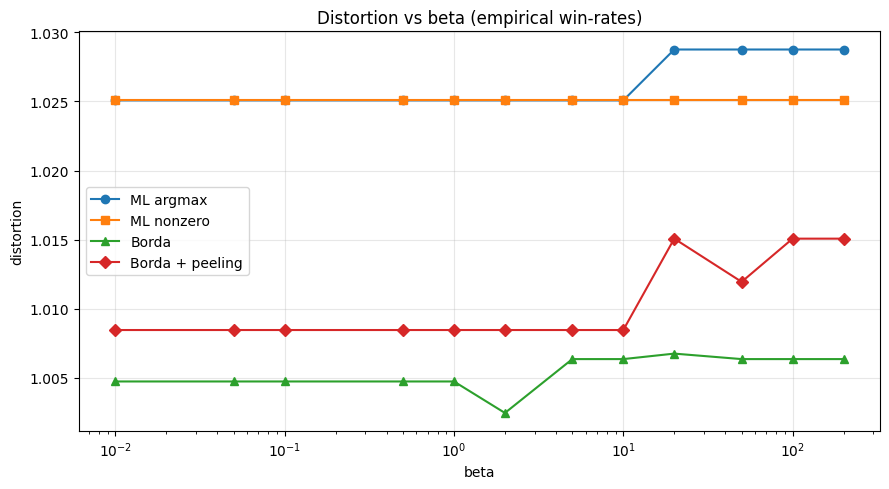

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(betas, dist_ml_argmax,  marker='o', label='ML argmax')
ax.plot(betas, dist_ml_nonzero, marker='s', label='ML nonzero')
ax.plot(betas, dist_borda_b,    marker='^', label='Borda')
ax.plot(betas, dist_borda_pb,   marker='D', label='Borda + peeling')

ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title('Distortion vs beta (empirical win-rates)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Distortion vs beta — fixed weight set

In [31]:
def leaderboard_dist_w(ranking, true_ranking, avg_utils, w):
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)
    num   = (avg_utils[true_ranking] * w).sum()
    denom = (avg_utils[ranking]      * w).sum()
    return num / denom, None

w = 1 / (1.1 ** np.arange(pw.M))

# initial distortions at raw margin_wins
dist_argmax_w,  _ = leaderboard_dist_w(ranking_argmax,       true_ranking, population.avg_utilities, w)
dist_nonzero_w, _ = leaderboard_dist_w(ranking_nonzero,      true_ranking, population.avg_utilities, w)
dist_borda_w,   _ = leaderboard_dist_w(borda_ranking,        true_ranking, population.avg_utilities, w)
dist_borda_pw,  _ = leaderboard_dist_w(borda_peeling_ranking,true_ranking, population.avg_utilities, w)

print(f"ML argmax  distortion (w): {dist_argmax_w:.6f}")
print(f"ML nonzero distortion (w): {dist_nonzero_w:.6f}")
print(f"Borda            dist (w): {dist_borda_w:.6f}")
print(f"Borda + peeling  dist (w): {dist_borda_pw:.6f}")

ML argmax  distortion (w): 1.003611
ML nonzero distortion (w): 1.004491
Borda            dist (w): 1.000384
Borda + peeling  dist (w): 1.000830


In [32]:
def all_four_distortions_w_at_beta(margin_wins, beta, true_ranking, avg_utils, w, mu_weight, total):
    m_beta = 2.0 * expit(beta * margin_wins) - 1.0
    np.fill_diagonal(m_beta, 0.0)

    wp_beta = expit(beta * margin_wins)
    np.fill_diagonal(wp_beta, 0.0)

    _, r_argmax  = argmax_lottery_from_wins(margins=m_beta)
    _, r_nonzero = nonzero_max_from_wins(margins=m_beta)
    r_borda         = np.argsort(-(wp_beta * mu_weight).sum(axis=1))
    r_borda_peeling = borda_ranking_peeling_mu(wp_beta, total)

    da,  _ = leaderboard_dist_w(r_argmax,        true_ranking, avg_utils, w)
    dn,  _ = leaderboard_dist_w(r_nonzero,       true_ranking, avg_utils, w)
    db,  _ = leaderboard_dist_w(r_borda,         true_ranking, avg_utils, w)
    dbp, _ = leaderboard_dist_w(r_borda_peeling, true_ranking, avg_utils, w)

    return da, dn, db, dbp


dist_ml_argmax_w  = []
dist_ml_nonzero_w = []
dist_borda_bw     = []
dist_borda_pbw    = []

for beta in betas:
    da, dn, db, dbp = all_four_distortions_w_at_beta(
        margin_wins, beta, true_ranking, population.avg_utilities, w, mu_weight, total
    )
    dist_ml_argmax_w.append(da)
    dist_ml_nonzero_w.append(dn)
    dist_borda_bw.append(db)
    dist_borda_pbw.append(dbp)
    print(f"beta={beta:7.2f}  ML-argmax={da:.4f}  ML-nonzero={dn:.4f}  Borda={db:.4f}  Borda+peel={dbp:.4f}")

print("done")

/tmp/ipykernel_431448/2697687476.py:11: RuntimeWarning: invalid value encountered in divide
  sub_weight  = np.where(count_i_rem > 0, sub_total / count_i_rem, 0.0)


beta=   0.01  ML-argmax=1.0036  ML-nonzero=1.0045  Borda=1.0004  Borda+peel=1.0008
beta=   0.05  ML-argmax=1.0036  ML-nonzero=1.0045  Borda=1.0004  Borda+peel=1.0008
beta=   0.10  ML-argmax=1.0036  ML-nonzero=1.0045  Borda=1.0004  Borda+peel=1.0008
beta=   0.50  ML-argmax=1.0036  ML-nonzero=1.0045  Borda=1.0004  Borda+peel=1.0008
beta=   1.00  ML-argmax=1.0036  ML-nonzero=1.0045  Borda=1.0002  Borda+peel=1.0008
beta=   2.00  ML-argmax=1.0036  ML-nonzero=1.0045  Borda=1.0002  Borda+peel=1.0009
beta=   5.00  ML-argmax=1.0036  ML-nonzero=1.0045  Borda=1.0005  Borda+peel=1.0010
beta=  10.00  ML-argmax=1.0036  ML-nonzero=1.0045  Borda=1.0007  Borda+peel=1.0010
beta=  20.00  ML-argmax=1.0040  ML-nonzero=1.0045  Borda=1.0010  Borda+peel=1.0023
beta=  50.00  ML-argmax=1.0048  ML-nonzero=1.0046  Borda=1.0010  Borda+peel=1.0018
beta= 100.00  ML-argmax=1.0048  ML-nonzero=1.0046  Borda=1.0013  Borda+peel=1.0020
beta= 200.00  ML-argmax=1.0048  ML-nonzero=1.0046  Borda=1.0012  Borda+peel=1.0021
done

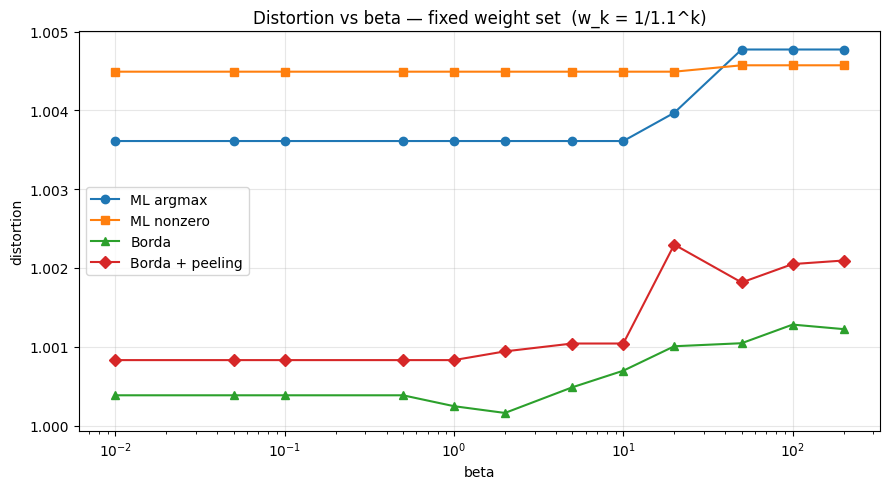

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(betas, dist_ml_argmax_w,  marker='o', label='ML argmax')
ax.plot(betas, dist_ml_nonzero_w, marker='s', label='ML nonzero')
ax.plot(betas, dist_borda_bw,     marker='^', label='Borda')
ax.plot(betas, dist_borda_pbw,    marker='D', label='Borda + peeling')

ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title('Distortion vs beta — fixed weight set  (w_k = 1/1.1^k)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()